# DAB 304 Project Work — BRFSS 2021 (CVD Risk Prediction)

This notebook completes the following task tasks:
- Data import + validation
- Data cleaning/prep
- EDA (plots + summaries)
- **4 hypothesis tests** with effect sizes
- Logistic Regression model (AUROC, Recall, Confusion Matrix)
- Simple fairness checks across **Sex** and **Age_Category**


In [1]:
# 1) Load data
import pandas as pd
import numpy as np


df = pd.read_csv("CDV.csv")

In [2]:
print('Shape:', df.shape)
df.head().T

Shape: (308854, 19)


,0,1,2,3,4
General_Health,Poor,Very Good,Very Good,Poor,Good
Checkup,Within the past 2 years,Within the past year,Within the past year,Within the past year,Within the past year
Exercise,No,No,Yes,Yes,No
Heart_Disease,No,Yes,No,Yes,No
Skin_Cancer,No,No,No,No,No
Other_Cancer,No,No,No,No,No
Depression,No,No,No,No,No
Diabetes,No,Yes,Yes,Yes,No
Arthritis,Yes,No,No,No,No
Sex,Female,Female,Female,Male,Male


In [3]:
# 2) Quick validation checks
print('Columns:', list(df.columns))
print('\nMissing values per column:')
print(df.isna().sum())
print('\nDtypes:')
print(df.dtypes)

# Basic summaries
print('\nNumeric summary:')
display(df.select_dtypes(include=[np.number]).describe().T)


Columns: ['General_Health', 'Checkup', 'Exercise', 'Heart_Disease', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']

Missing values per column:
General_Health                  0
Checkup                         0
Exercise                        0
Heart_Disease                   0
Skin_Cancer                     0
Other_Cancer                    0
Depression                      0
Diabetes                        0
Arthritis                       0
Sex                             0
Age_Category                    0
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Smoking_History                 0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype:

,count,mean,std,min,25%,50%,75%,max
Height_(cm),308854.0,170.615249,10.658026,91.00,163.00,170.00,178.00,241.00
Weight_(kg),308854.0,83.588655,21.343210,24.95,68.04,81.65,95.25,293.02
BMI,308854.0,28.626211,6.522323,12.02,24.21,27.44,31.85,99.33
Alcohol_Consumption,308854.0,5.096366,8.199763,0.00,0.00,1.00,6.00,30.00
Fruit_Consumption,308854.0,29.835200,24.875735,0.00,12.00,30.00,30.00,120.00
Green_Vegetables_Consumption,308854.0,15.110441,14.926238,0.00,4.00,12.00,20.00,128.00
FriedPotato_Consumption,308854.0,6.296616,8.582954,0.00,2.00,4.00,8.00,128.00


In [4]:
df['Heart_Disease'].unique()

array(['No', 'Yes'], dtype=object)

In [5]:
df['Heart_Disease'].value_counts()

Heart_Disease
No     283883
Yes     24971
Name: count, dtype: int64

In [6]:
percentages = df['Heart_Disease'].value_counts(normalize=True) * 100
print(percentages)

Heart_Disease
No     91.91495
Yes     8.08505
Name: proportion, dtype: float64


In [21]:
print(df["Sex"].value_counts(dropna=False))

Sex
Female    160196
Male      148658
Name: count, dtype: int64


In [7]:
# 3) Cleaning / preparation
# Standardize string columns (strip spaces)
for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].astype(str).str.strip()

# Target: Heart_Disease (Yes/No)
target_col = 'Heart_Disease'

# Map common yes/no style values
yn_map = {'Yes': 1, 'No': 0 }

df[target_col] = df[target_col].map(yn_map)

# Validate target mapping
print('Target value counts (after mapping):')
print(df[target_col].value_counts(dropna=False))

# Drop rows where target could not be mapped (should be none)
before = len(df)
df = df.dropna(subset=[target_col]).copy()
after = len(df)
print(f'Rows kept after target cleanup: {after} (dropped {before-after})')

# Identifying numeric and categorical columns
numeric_cols = ['Height_(cm)', 'Weight_(kg)', 'BMI', 'Alcohol_Consumption', 'Fruit_Consumption',
                'Green_Vegetables_Consumption', 'FriedPotato_Consumption']


categorical_cols = [c for c in df.columns if c not in numeric_cols + [target_col]]
print('Numeric cols:', numeric_cols)
print('Categorical cols:', categorical_cols)

# Convert numeric columns to numeric safely
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print('\nMissing after numeric coercion (numeric cols):')
print(df[numeric_cols].isna().sum())

# Simple missing strategy: drop rows with missing numeric values
before = len(df)
df = df.dropna(subset=numeric_cols).copy()
after = len(df)
print(f'Rows kept after dropping missing numeric: {after} (dropped {before-after})')


Target value counts (after mapping):
Heart_Disease
0    283883
1     24971
Name: count, dtype: int64
Rows kept after target cleanup: 308854 (dropped 0)
Numeric cols: ['Height_(cm)', 'Weight_(kg)', 'BMI', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']
Categorical cols: ['General_Health', 'Checkup', 'Exercise', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Smoking_History']

Missing after numeric coercion (numeric cols):
Height_(cm)                     0
Weight_(kg)                     0
BMI                             0
Alcohol_Consumption             0
Fruit_Consumption               0
Green_Vegetables_Consumption    0
FriedPotato_Consumption         0
dtype: int64
Rows kept after dropping missing numeric: 308854 (dropped 0)


Class counts:
Heart_Disease
0    283883
1     24971
Name: count, dtype: int64
Class %:
Heart_Disease
0    91.91
1     8.09
Name: count, dtype: float64


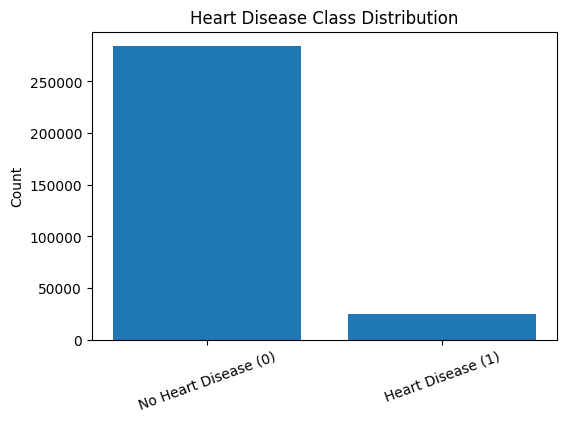

In [8]:
# 4) EDA — class balance
import matplotlib.pyplot as plt

counts = df[target_col].value_counts().sort_index()
labels = ['No Heart Disease (0)', 'Heart Disease (1)']
print('Class counts:')
print(counts)
print('Class %:')
print((counts / counts.sum() * 100).round(2))

plt.figure(figsize=(6,4))
plt.bar(labels, counts.values)
plt.title('Heart Disease Class Distribution')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()

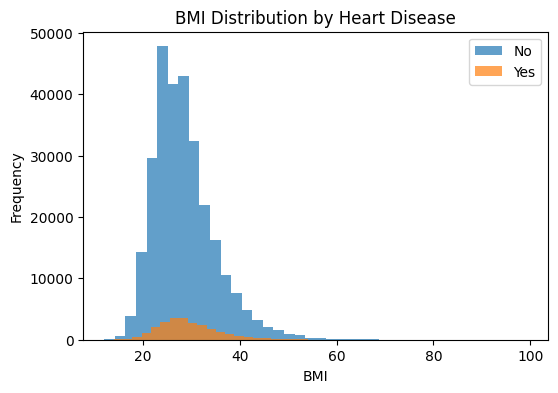

Heart_Disease,0,1
Age_Category,,
18-24,0.994968,0.005032
25-29,0.992707,0.007293
30-34,0.989093,0.010907
35-39,0.986703,0.013297
40-44,0.979856,0.020144
45-49,0.967665,0.032335
50-54,0.952943,0.047057
55-59,0.929030,0.070970
60-64,0.907089,0.092911


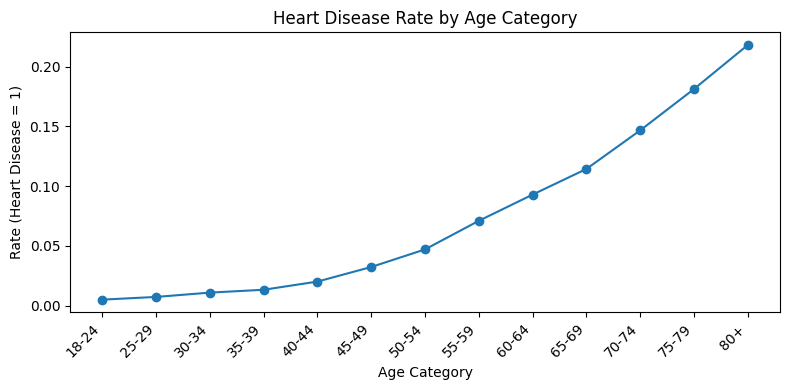

Heart_Disease,0,1
Sex,,
Female,0.938213,0.061787
Male,0.898606,0.101394


In [9]:
# 5) EDA — key distributions and relationships
import matplotlib.pyplot as plt

# BMI by target
plt.figure(figsize=(6,4))
plt.hist(df.loc[df[target_col]==0, 'BMI'], bins=40, alpha=0.7, label='No')
plt.hist(df.loc[df[target_col]==1, 'BMI'], bins=40, alpha=0.7, label='Yes')
plt.title('BMI Distribution by Heart Disease')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Age_Category vs target (proportions)
age_ct = pd.crosstab(df['Age_Category'], df[target_col], normalize='index')
display(age_ct)

plt.figure(figsize=(8,4))
plt.plot(age_ct.index, age_ct[1], marker='o')
plt.title('Heart Disease Rate by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Rate (Heart Disease = 1)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Sex vs target
sex_ct = pd.crosstab(df['Sex'], df[target_col], normalize='index')
display(sex_ct)


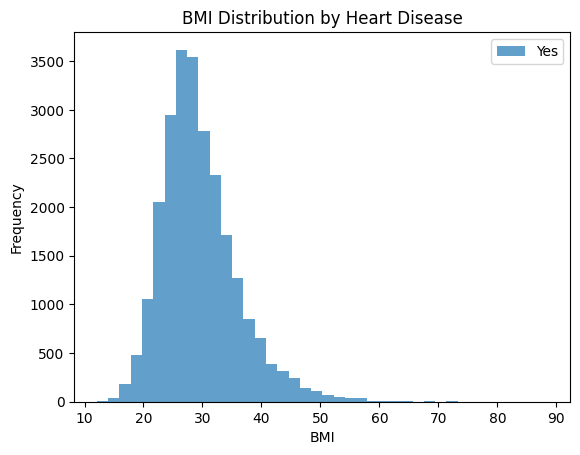

In [19]:
plt.hist(df.loc[df[target_col]==1, 'BMI'], bins=40, alpha=0.7, label='Yes')
plt.title('BMI Distribution by Heart Disease')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.legend()
plt.show()

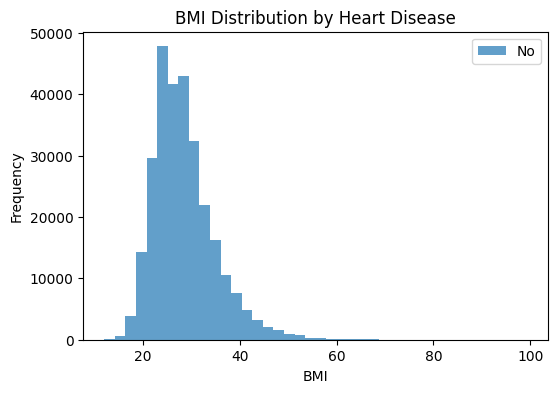

In [20]:
plt.figure(figsize=(6,4))
plt.hist(df.loc[df[target_col]==0, 'BMI'], bins=40, alpha=0.7, label='No')

plt.title('BMI Distribution by Heart Disease')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Test 1 & 2: Chi-Square Test of Independence (categorical vs categorical)

What it is:
A statistical test to check whether two categorical variables are related (associated) or not.

Used for:

Smoking_History (categories) vs Heart_Disease (Yes/No)

Exercise (Yes/No) vs Heart_Disease (Yes/No)

H0 (Null): the two variables are independent (no relationship).
H1 (Alternative): the two variables are not independent (there is a relationship).

Formula (Chi-square statistic):

𝜒^2=∑(𝑂𝑖𝑗−𝐸𝑖𝑗)^2/𝐸𝑖𝑗

Where:

𝑂𝑖𝑗 = observed frequency in cell 𝑖,𝑗


Eij = expected frequency if variables were independent

Expected count formula:

𝐸𝑖𝑗 = (row total𝑖)(column total𝑗)/𝑛


Test 3:  Two-Sample t-Test (numeric vs binary group)

What it is:
A test to check if the average (mean) of a numeric variable is different between two groups.
Welch version is used when variances may be unequal (safer than the “equal variance” t-test).

Used for:

BMI (numeric) comparing Heart_Disease=Yes vs Heart_Disease=No

H0: 𝜇𝑌𝑒𝑠 = 𝜇𝑁𝑜 (mean BMI is the same).
H1: 𝜇𝑌𝑒𝑠 ≠ 𝜇𝑁𝑜 (mean BMI is different).

Formula ( t statistic):

𝑡 = 𝑥1−𝑥2/𝑠qr(s1^2/𝑛1+𝑠2^2/𝑛2)


Where:

𝑥1,𝑥2 = sample means

𝑠1^2,𝑠2^2 = sample variances

𝑛1,𝑛2 = sample sizes

p-value tells you “is there evidence of a relationship/difference?”

effect size tells you “how strong is it / how big is the difference?”

Some lecturers like effect sizes because they show deeper understanding, but if you were not asked for effect sizes, you can skip them.

Defines effect sizes

Cramer’s V → shows strength of association for chi-square (0 = no relationship, higher = stronger)

Cohen’s d → shows size of mean difference (rough guide: 0.2 small, 0.5 medium, 0.8 large)

Test 4 ANOVA Test (Analysis of Variance)
ANOVA is a statistical test used to compare the means of 3 or more groups to check if at least one group mean is different from the others.

Formular (F-Statistic)
F=MSW/MSB

Where:
Mean Square Between (MSB)
𝑀𝑆𝐵=∑𝑛𝑖(𝑋ˉ𝑖−𝑋ˉ)^2/𝑘−1

Mean Square Within (MSW)
𝑀𝑆𝑊=∑(𝑋𝑖𝑗−𝑋ˉ𝑖)^2/𝑁−𝑘

Xˉi = mean BMI in each age group
Xˉ = overall mean BMI
𝑛𝑖 = number of people in each group
k = number of age groups
N = total observations

H0: The mean BMI is the same across all Age_Category groups.
H1: At least one Age_Category group has a different mean BMI.

Null (H0) and Alternative (H1)
Test 1: Smoking_History vs Heart_Disease (Chi-square)

H0: Smoking history and heart disease are independent (no relationship).

H1: Smoking history and heart disease are associated (there is a relationship).

Test 2: Exercise vs Heart_Disease (Chi-square)

H0: Exercise and heart disease are independent.

H1: Exercise and heart disease are associated.

Test 3: BMI by Heart_Disease (Welch t-test)

H0: Mean BMI is the same for people with and without heart disease.

𝜇𝐵𝑀𝐼,𝐻𝐷=1 = 𝜇𝐵𝑀,𝐻𝐷=0

H1: Mean BMI is different between the two groups.

𝜇𝐵𝑀𝐼,𝐻𝐷=1 ≠ 𝜇𝐵𝑀𝐼,𝐻𝐷=0

Test 4: Mean BMI across different age_groups.

H0: The mean BMI is the same across all Age_Category groups.
H0​:μ1​=μ2​=μ3​=⋯=μk​

H1: At least one Age_Category group has a different mean BMI.
H1​:At least one μi​ ≠ μj

In [17]:
import pandas as pd
from scipy.stats import chi2_contingency, ttest_ind

target = "Heart_Disease"   # must already be 0/1
alpha = 0.05

# -------------------
# Test 1: Chi-square (Smoking_History vs Heart_Disease)
# -------------------
print("TEST 1: Chi-square — Smoking_History vs Heart_Disease")
print("H0: Smoking_History and Heart_Disease are independent.")
print("H1: Smoking_History and Heart_Disease are associated.\n")

tab1 = pd.crosstab(df["Smoking_History"], df[target])
chi2_1, p1, dof1, exp1 = chi2_contingency(tab1)

display(tab1)
print(f"Chi-square statistic = {chi2_1:.4f}")
print(f"Degrees of freedom = {dof1}")
print(f"p-value = {p1:.3e}")
#print("Decision:", "Reject H0" if p1 < alpha else "Fail to reject H0")
# Decision
if p1 < alpha:
    print("\nDecision: Reject H0")
    print("Interpretation: There is enough evidence to conclude that Smoking_History and Heart_Disease are associated.")
else:
    print("\nDecision: Fail to reject H0")
    print("Interpretation: There is not enough evidence to conclude that Smoking_History and Heart_Disease are associated.")
print("\n" + "-"*60 + "\n")

# -------------------
# Test 2: Chi-square (Exercise vs Heart_Disease)
# -------------------
print("TEST 2: Chi-square — Exercise vs Heart_Disease")
print("H0: Exercise and Heart_Disease are independent.")
print("H1: Exercise and Heart_Disease are associated.\n")

tab2 = pd.crosstab(df["Exercise"], df[target])
chi2_2, p2, dof2, exp2 = chi2_contingency(tab2)

display(tab2)
print(f"Chi-square statistic = {chi2_2:.4f}")
print(f"Degrees of freedom = {dof2}")
print(f"p-value = {p2:.3e}")
#print("Decision:", "Reject H0" if p2 < alpha else "Fail to reject H0")
# Decision
if p2 < alpha:
    print("\nDecision: Reject H0")
    print("Interpretation: There is enough evidence to conclude that Exercise and Heart_Disease are associated.")
else:
    print("\nDecision: Fail to reject H0")
    print("Interpretation: There is not enough evidence to conclude that Exercise and Heart_Disease are associated.")
print("\n" + "-"*60 + "\n")

# -------------------
# Test 3: Welch t-test (BMI difference)
# -------------------
print("TEST 3: Welch t-test — BMI by Heart_Disease")
print("H0: Mean BMI is the same for Heart_Disease=1 and Heart_Disease=0.")
print("H1: Mean BMI is different between the two groups.\n")

bmi_no  = df.loc[df[target] == 0, "BMI"].dropna()
bmi_yes = df.loc[df[target] == 1, "BMI"].dropna()

t_stat, p3 = ttest_ind(bmi_yes, bmi_no, equal_var=False)

print(f"Mean BMI (No)  = {bmi_no.mean():.3f}  n={len(bmi_no)}")
print(f"Mean BMI (Yes) = {bmi_yes.mean():.3f}  n={len(bmi_yes)}")
print(f"t-statistic = {t_stat:.4f}")
print(f"p-value = {p3:.3e}")
#print("Decision:", "Reject H0" if p3 < alpha else "Fail to reject H0")
# Decision
if p3 < alpha:
    print("\nDecision: Reject H0")
    print("Interpretation: There is enough evidence to conclude that Mean BMI is  different for Heart_Disease=1 and Heart_Disease=0.")
else:
    print("\nDecision: Fail to reject H0")
    print("Interpretation: There is not enough evidence to conclude that Mean BMI is different between the two groups.")

TEST 1: Chi-square — Smoking_History vs Heart_Disease
H0: Smoking_History and Heart_Disease are independent.
H1: Smoking_History and Heart_Disease are associated.



Heart_Disease,0,1
Smoking_History,,
No,173203,10387
Yes,110680,14584


Chi-square statistic = 3588.1356
Degrees of freedom = 1
p-value = 0.000e+00

Decision: Reject H0
Interpretation: There is enough evidence to conclude that Smoking_History and Heart_Disease are associated.

------------------------------------------------------------

TEST 2: Chi-square — Exercise vs Heart_Disease
H0: Exercise and Heart_Disease are independent.
H1: Exercise and Heart_Disease are associated.



Heart_Disease,0,1
Exercise,,
No,60469,9004
Yes,223414,15967


Chi-square statistic = 2866.1545
Degrees of freedom = 1
p-value = 0.000e+00

Decision: Reject H0
Interpretation: There is enough evidence to conclude that Exercise and Heart_Disease are associated.

------------------------------------------------------------

TEST 3: Welch t-test — BMI by Heart_Disease
H0: Mean BMI is the same for Heart_Disease=1 and Heart_Disease=0.
H1: Mean BMI is different between the two groups.

Mean BMI (No)  = 28.544  n=283883
Mean BMI (Yes) = 29.565  n=24971
t-statistic = 23.5396
p-value = 2.127e-121

Decision: Reject H0
Interpretation: There is enough evidence to conclude that Mean BMI is  different for Heart_Disease=1 and Heart_Disease=0.


In [11]:
import pandas as pd
from scipy.stats import f_oneway

# ---------------------------------------
# One-Way ANOVA: BMI across Age_Category
# ---------------------------------------
# H0: The mean BMI is the same across all Age_Category groups.
# H1: At least one Age_Category group has a different mean BMI.

alpha = 0.05

# Clean and prepare the variables used in the test
df_anova = df.dropna(subset=["BMI", "Age_Category"]).copy()

age_order = [
    "18-24","25-29","30-34","35-39","40-44","45-49",
    "50-54","55-59","60-64","65-69","70-74","75-79","80+"
]

# Create a list of BMI values for each age group
groups = []
group_names = []
for age in age_order:
    sub = df.loc[df["Age_Category"] == age, "BMI"].dropna()
    if len(sub) > 0:
        groups.append(sub)
        group_names.append(age)

# Run the ANOVA test
f_stat, p_value = f_oneway(*groups)

print("ONE-WAY ANOVA TEST")
print("H0: The mean BMI is the same across all Age_Category groups.")
print("H1: At least one Age_Category group has a different mean BMI.")
print("-" * 60)

# Show group means
summary = (
    df_anova.groupby("Age_Category")["BMI"]
      .agg(["mean", "count", "std"])
      .reset_index()
)
print("Group summary:")
print(summary.to_string(index=False))

print("\nANOVA result:")
print(f"F-statistic = {f_stat:.4f}")
print(f"p-value     = {p_value:.3e}")

# Decision
if p_value < alpha:
    print("\nDecision: Reject H0")
    print("Interpretation: There is enough evidence to conclude that mean BMI is not the same across all age groups.")
else:
    print("\nDecision: Fail to reject H0")
    print("Interpretation: There is not enough evidence to conclude that mean BMI differs across the age groups.")

ONE-WAY ANOVA TEST
H0: The mean BMI is the same across all Age_Category groups.
H1: At least one Age_Category group has a different mean BMI.
------------------------------------------------------------
Group summary:
Age_Category      mean  count      std
       18-24 26.005244  18681 6.349482
       25-29 27.896320  15494 6.888032
       30-34 28.583358  18428 6.852590
       35-39 29.106485  20606 6.994590
       40-44 29.480708  21595 7.065529
       45-49 29.811623  20968 6.988912
       50-54 29.789274  25097 6.879488
       55-59 29.458286  28054 6.655670
       60-64 29.195906  32418 6.495752
       65-69 28.849865  33434 6.212615
       70-74 28.446730  31103 5.842893
       75-79 27.883289  20705 5.445610
         80+ 26.396487  22271 4.903168

ANOVA result:
F-statistic = 756.8110
p-value     = 0.000000e+00

Decision: Reject H0
Interpretation: There is enough evidence to conclude that mean BMI is not the same across all age groups.


In [26]:
#import pandas as pd
#from scipy.stats import chi2_contingency

# ---------------------------------------------------------
# Chi-Square Test: Sex vs Heart_Disease
# ---------------------------------------------------------
# H0: Sex and Heart_Disease are independent.
#     (Male and female have the same likelihood of heart disease)
#
# H1: Sex and Heart_Disease are associated.
#     (Male and female do not have the same likelihood of heart disease)

alpha = 0.05

# Clean and prepare the variables used in the test
df_test = df.dropna(subset=["Sex", "Heart_Disease"]).copy()

# Create contingency table
table = pd.crosstab(df_test["Sex"], df_test["Heart_Disease"])

# Run the Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(table)

print("CHI-SQUARE TEST: SEX vs HEART_DISEASE")
print("H0: Sex and Heart_Disease are independent.")
print("H1: Sex and Heart_Disease are associated.")
print("-" * 60)

# Show observed counts
print("Observed contingency table:")
print(table.to_string())

# Show expected counts
expected_df = pd.DataFrame(
    expected,
    index=table.index,
    columns=table.columns
)

print("\nExpected counts table:")
print(expected_df.round(2).to_string())

# Show proportions within each sex group
proportions = table.div(table.sum(axis=1), axis=0)

print("\nProportion of Heart Disease within each sex:")
print(proportions.round(4).to_string())

print("\nChi-Square result:")
print(f"Chi-square statistic = {chi2:.4f}")
print(f"Degrees of freedom   = {dof}")
print(f"p-value              = {p_value:.3e}")

# Decision
if p_value < alpha:
    print("\nDecision: Reject H0")
    print("Interpretation: There is enough evidence to conclude that heart disease likelihood differs by sex.")

    # Extra interpretation: check which sex has higher proportion of heart disease
    if "Yes" in proportions.columns:
        male_rate = proportions.loc["Male", "Yes"] if "Male" in proportions.index else None
        female_rate = proportions.loc["Female", "Yes"] if "Female" in proportions.index else None

        if male_rate is not None and female_rate is not None:
            print(f"\nMale heart disease proportion   = {male_rate:.4f}")
            print(f"Female heart disease proportion = {female_rate:.4f}")

            if male_rate > female_rate:
                print("Conclusion: Males are more likely to have heart disease than females in this dataset.")
            elif female_rate > male_rate:
                print("Conclusion: Females are more likely to have heart disease than males in this dataset.")
            else:
                print("Conclusion: The proportions are equal in this dataset.")
else:
    print("\nDecision: Fail to reject H0")
    print("Interpretation: There is not enough evidence to conclude that heart disease likelihood differs by sex.")

CHI-SQUARE TEST: SEX vs HEART_DISEASE
H0: Sex and Heart_Disease are independent.
H1: Sex and Heart_Disease are associated.
------------------------------------------------------------
Observed contingency table:
Heart_Disease       0      1
Sex                         
Female         150298   9898
Male           133585  15073

Expected counts table:
Heart_Disease          0         1
Sex                               
Female         147244.07  12951.93
Male           136638.93  12019.07

Proportion of Heart Disease within each sex:
Heart_Disease       0       1
Sex                          
Female         0.9382  0.0618
Male           0.8986  0.1014

Chi-Square result:
Chi-square statistic = 1627.1192
Degrees of freedom   = 1
p-value              = 0.000e+00

Decision: Reject H0
Interpretation: There is enough evidence to conclude that heart disease likelihood differs by sex.


In [12]:
# 7) Model — Logistic Regression (one-hot categorical + scaled numeric)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, accuracy_score, confusion_matrix, classification_report
import joblib

X = df[categorical_cols + numeric_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

model = LogisticRegression(max_iter=200, n_jobs=None)

pipe = Pipeline(steps=[('prep', preprocess), ('model', model)])
pipe.fit(X_train, y_train)

# Predictions
proba = pipe.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, proba)
rec = recall_score(y_test, pred)
acc = accuracy_score(y_test, pred)
cm = confusion_matrix(y_test, pred)

print(f"AUROC: {auc:.4f}")
print(f"Recall (positive class=1): {rec:.4f}")
print(f"Accuracy: {acc:.4f}\n")
print('Confusion Matrix [ [TN FP] [FN TP] ]:')
print(cm)
print('\nClassification report:')
print(classification_report(y_test, pred, digits=4))

joblib.dump(pipe, 'cvd_logreg_pipeline.joblib')
print("Saved model: cvd_logreg_pipeline.joblib")


AUROC: 0.8390
Recall (positive class=1): 0.0611
Accuracy: 0.9191

Confusion Matrix [ [TN FP] [FN TP] ]:
[[56471   306]
 [ 4689   305]]

Classification report:
              precision    recall  f1-score   support

           0     0.9233    0.9946    0.9576     56777
           1     0.4992    0.0611    0.1088      4994

    accuracy                         0.9191     61771
   macro avg     0.7113    0.5278    0.5332     61771
weighted avg     0.8890    0.9191    0.8890     61771



In [37]:
# 8) Model interpretability — top coefficients
# Get feature names after one-hot
import numpy as np

ohe = pipe.named_steps['prep'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

coefs = pipe.named_steps['model'].coef_.ravel()
coef_df = pd.DataFrame({'feature': all_feature_names, 'coef': coefs})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

print('Top 20 strongest coefficients (by absolute value):')
display(coef_df[['feature','abs_coef']].head(20))


Top 20 strongest coefficients (by absolute value):


,feature,abs_coef
26,Age_Category_18-24,1.636425
38,Age_Category_80+,1.591050
27,Age_Category_25-29,1.400917
37,Age_Category_75-79,1.309607
0,General_Health_Excellent,1.234172
28,Age_Category_30-34,1.206446
36,Age_Category_70-74,1.084223
29,Age_Category_35-39,1.061456
3,General_Health_Poor,1.033124
35,Age_Category_65-69,0.812994


In [15]:
# 9) Simple fairness checks — metrics by Sex and Age_Category
from sklearn.metrics import roc_auc_score, recall_score

def group_metrics(group_col):
    out = []
    for g, sub in X_test.assign(y=y_test.values, proba=proba, pred=pred).groupby(group_col):
        y_g = sub['y'].values
        p_g = sub['proba'].values
        pred_g = sub['pred'].values
        # AUROC needs both classes present; if not, set NaN
        try:
            auc_g = roc_auc_score(y_g, p_g)
        except ValueError:
            auc_g = np.nan
        rec_g = recall_score(y_g, pred_g, zero_division=0)
        out.append((g, len(sub), auc_g, rec_g))
    return pd.DataFrame(out, columns=[group_col, 'n', 'AUROC', 'Recall'])

sex_metrics = group_metrics('Sex')
age_metrics = group_metrics('Age_Category')

print('By Sex:')
display(sex_metrics.sort_values('n', ascending=False))
print('By Age_Category (sorted by age label):')
display(age_metrics)

By Sex:


,Sex,n,AUROC,Recall
0,Female,32176,0.830794,0.017387
1,Male,29595,0.837521,0.090574


By Age_Category (sorted by age label):


,Age_Category,n,AUROC,Recall
0,18-24,3730,0.686665,0.000000
1,25-29,3194,0.654000,0.000000
2,30-34,3722,0.707053,0.000000
3,35-39,4096,0.779270,0.000000
4,40-44,4338,0.805246,0.000000
5,45-49,4136,0.788179,0.000000
6,50-54,4927,0.778476,0.000000
7,55-59,5551,0.795293,0.005076
8,60-64,6366,0.763574,0.016639
9,65-69,6784,0.750897,0.024390


In [16]:
print("Accuracy:", accuracy_score(y_test, pred))
#print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
#print("F1:", f1_score(y_test, pred))
print("AUROC:", roc_auc_score(y_test, proba))
print("Confusion Matrix:")
print(confusion_matrix(y_test, pred))
print('\nClassification report:')
print(classification_report(y_test, pred, digits=4))

Accuracy: 0.9191368117725146
Recall: 0.06107328794553464
AUROC: 0.8390080495982254
Confusion Matrix:
[[56471   306]
 [ 4689   305]]

Classification report:
              precision    recall  f1-score   support

           0     0.9233    0.9946    0.9576     56777
           1     0.4992    0.0611    0.1088      4994

    accuracy                         0.9191     61771
   macro avg     0.7113    0.5278    0.5332     61771
weighted avg     0.8890    0.9191    0.8890     61771

